# Preparación del Dataset y Modelado Attrition Dataset

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import optuna
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

with open('../data/attrition_dataset.pkl', 'rb') as f:
    df = pd.read_pickle('../data/attrition_dataset.pkl')

df = df.reset_index(drop=True)
print(f'Shape original: {df.shape}')

Shape original: (1426, 31)


##  Metricas a usar

Se utilizan dos métricas de evaluación. Accuracy mide el porcentaje de predicciones correctas sobre el total. AUC-ROC mide la capacidad discriminativa del modelo evaluando qué tan bien separa las probabilidades de los empleados que se van vs los que se quedan, independientemente del umbral de clasificación elegido. Dado que el dataset está balanceado (50/50), ambas métricas son igualmente válidas en este caso, pero se prioriza AUC-ROC por ser la métrica estándar en problemas de clasificación binaria donde el desbalance de clases es frecuente en datos reales de Attrition.

## 1. Eliminación de Variables sin Aporte

Según el EDA, las siguientes variables se descartan:
- `EmployeeCount`, `StandardHours`, `Over18`: valor constante en todos los registros, sin variabilidad
- `EmployeeID`: identificador único, no predictivo

In [37]:
cols_to_drop = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeID']
df = df.drop(columns=cols_to_drop)
print(f'Shape luego de eliminar variables: {df.shape}')

Shape luego de eliminar variables: (1426, 27)


## 2. Feature Engineering

Se crean las 8 variables derivadas. Los NaN que puedan propagarse desde variables con nulos serán imputados en el paso siguiente, después del split.

In [38]:
sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'JobInvolvement']
df['satisfaction_index']    = df[sat_cols].mean(axis=1)
df['company_tenure_ratio']  = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)
df['promotion_stagnation']  = df['YearsSinceLastPromotion'] / (df['YearsAtCompany'] + 1)
df['manager_loyalty_ratio'] = df['YearsWithCurrManager'] / (df['YearsAtCompany'] + 1)
df['experience_density']    = df['TotalWorkingYears'] / (df['Age'] - 17)
df['overwork_pressure']     = df['hrs'] / (df['WorkLifeBalance'] + 0.5)
df['anchoring_score']       = df[['YearsAtCompany', 'TotalWorkingYears', 'YearsWithCurrManager']].mean(axis=1)

avg_income_by_level = df.groupby('JobLevel')['MonthlyIncome'].transform('mean')
df['income_vs_level'] = (df['MonthlyIncome'] - avg_income_by_level) / avg_income_by_level

print(f'Shape luego de feature engineering: {df.shape}')
print(f'Features creadas: satisfaction_index, company_tenure_ratio, promotion_stagnation,')
print(f'                  manager_loyalty_ratio, experience_density, overwork_pressure,')
print(f'                  anchoring_score, income_vs_level')

Shape luego de feature engineering: (1426, 35)
Features creadas: satisfaction_index, company_tenure_ratio, promotion_stagnation,
                  manager_loyalty_ratio, experience_density, overwork_pressure,
                  anchoring_score, income_vs_level


## 3. Separar X e y

In [39]:
X = df.drop(columns='Attrition')
y = (df['Attrition'] == 'Yes').astype(int)

print(f'X shape: {X.shape}  |  Nulos en X: {X.isnull().sum().sum()}')
print(f'y shape: {y.shape}')

X shape: (1426, 34)  |  Nulos en X: 874
y shape: (1426,)


## 4. Train/Test Split

Se divide primero, **antes de imputar y encodear**, para evitar data leakage. La mediana y el encoding se calcularán solo con los datos de train y luego se aplicarán al test.

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (1140, 34) | Test: (286, 34)


## 5. Imputación (fit solo en train)

Se calcula la mediana y la moda **únicamente con X_train**, luego se aplica al test. Así el test no influye en los valores de imputación.

In [41]:
num_cols = X_train.select_dtypes(include='number').columns
cat_cols = X_train.select_dtypes(include='object').columns

# Calcular estadísticos solo del train
medianas = X_train[num_cols].median()
modas    = {col: X_train[col].mode()[0] for col in cat_cols if X_train[col].isnull().any()}

# Imputar train
X_train = X_train.copy()
X_train[num_cols] = X_train[num_cols].fillna(medianas)
for col, moda in modas.items():
    X_train[col] = X_train[col].fillna(moda)

# Imputar test con los mismos valores del train
X_test = X_test.copy()
X_test[num_cols] = X_test[num_cols].fillna(medianas)
for col, moda in modas.items():
    X_test[col] = X_test[col].fillna(moda)

print(f'Nulos en X_train: {X_train.isnull().sum().sum()}')
print(f'Nulos en X_test:  {X_test.isnull().sum().sum()}')

Nulos en X_train: 0
Nulos en X_test:  0


## 6. Encoding (fit solo en train)

Se usa `OneHotEncoder` de sklearn con `fit` en train y `transform` en ambos. Así las categorías aprendidas son solo las del train.

In [42]:
from sklearn.preprocessing import OneHotEncoder

cat_cols_to_encode = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoder.fit(X_train[cat_cols_to_encode])

enc_cols = encoder.get_feature_names_out(cat_cols_to_encode)

X_train_enc = pd.DataFrame(encoder.transform(X_train[cat_cols_to_encode]), columns=enc_cols, index=X_train.index)
X_test_enc  = pd.DataFrame(encoder.transform(X_test[cat_cols_to_encode]),  columns=enc_cols, index=X_test.index)

X_train = pd.concat([X_train.drop(columns=cat_cols_to_encode), X_train_enc], axis=1)
X_test  = pd.concat([X_test.drop(columns=cat_cols_to_encode),  X_test_enc],  axis=1)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')

X_train shape: (1140, 48)
X_test shape:  (286, 48)


## Modelos

### 2.0 Regresión Logística

Se usa como **modelo base de referencia** antes de pasar a modelos más complejos. Si un modelo más complejo no supera significativamente a la regresión logística, la simplicidad e interpretabilidad de esta última la hacen preferible.

Accuracy: 0.7483
AUC-ROC:  0.8149

Classification Report:
              precision    recall  f1-score   support

          No       0.75      0.75      0.75       143
         Yes       0.75      0.75      0.75       143

    accuracy                           0.75       286
   macro avg       0.75      0.75      0.75       286
weighted avg       0.75      0.75      0.75       286



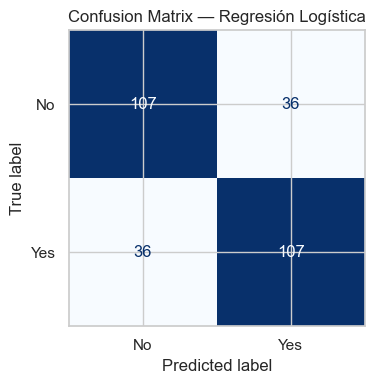

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, ConfusionMatrixDisplay

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

print(f'Accuracy: {acc_lr:.4f}')
print(f'AUC-ROC:  {auc_lr:.4f}')
print(f'\nClassification Report:\n{classification_report(y_test, y_pred_lr, target_names=["No", "Yes"])}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=['No', 'Yes'],
                                         colorbar=False, ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix — Regresión Logística')
plt.tight_layout()
plt.show()

### 2.1 XGBoost Base

Se entrena un XGBoost con parámetros por defecto como línea de base para ver si mejora o no la regresion.

Accuracy: 0.9231
AUC-ROC:  0.9835

Classification Report:
              precision    recall  f1-score   support

          No       0.98      0.86      0.92       143
         Yes       0.88      0.99      0.93       143

    accuracy                           0.92       286
   macro avg       0.93      0.92      0.92       286
weighted avg       0.93      0.92      0.92       286



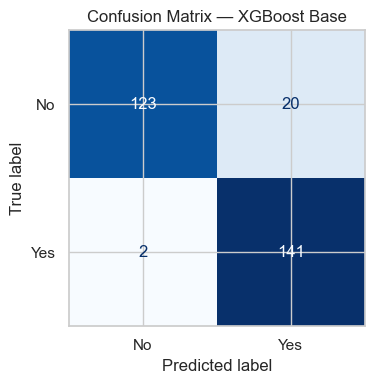

In [44]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, ConfusionMatrixDisplay

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_base.fit(X_train, y_train)

y_pred = xgb_base.predict(X_test)
y_prob = xgb_base.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f'Accuracy: {acc:.4f}')
print(f'AUC-ROC:  {auc:.4f}')
print(f'\nClassification Report:\n{classification_report(y_test, y_pred, target_names=["No", "Yes"])}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No', 'Yes'],
                                         colorbar=False, ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix — XGBoost Base')
plt.tight_layout()
plt.show()

In [45]:
y_pred_train = xgb_base.predict(X_train)
y_prob_train = xgb_base.predict_proba(X_train)[:, 1]

acc_train = accuracy_score(y_train, y_pred_train)
auc_train = roc_auc_score(y_train, y_prob_train)

print('           Train     Test')
print(f'Accuracy:  {acc_train:.4f}   {acc:.4f}')
print(f'AUC-ROC:   {auc_train:.4f}   {auc:.4f}')
print(f'\nDiferencia Accuracy: {acc_train - acc:.4f}')
print(f'Diferencia AUC-ROC:  {auc_train - auc:.4f}')

           Train     Test
Accuracy:  1.0000   0.9231
AUC-ROC:   1.0000   0.9835

Diferencia Accuracy: 0.0769
Diferencia AUC-ROC:  0.0165


### 2.2 XGBoost — Tuning de Hiperparámetros (Optuna)

 Se usa **Optuna** para optimizar los hiperparámetros. 

Se maximiza el AUC-ROC con 5-fold cross-validation.

In [46]:
import optuna
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
        'max_depth':        trial.suggest_int('max_depth', 2, 6),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 3.0),
    }
    model = XGBClassifier(**params, random_state=42, eval_metric='logloss')
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f'Mejor AUC-ROC (CV): {study.best_value:.4f}')
print(f'Mejores hiperparámetros:\n{study.best_params}')

  0%|          | 0/100 [00:00<?, ?it/s]

Mejor AUC-ROC (CV): 0.9559
Mejores hiperparámetros:
{'n_estimators': 348, 'max_depth': 6, 'learning_rate': 0.09576928837956669, 'subsample': 0.8115243928723399, 'colsample_bytree': 0.9593374629171209, 'min_child_weight': 1, 'reg_alpha': 0.3559560347626066, 'reg_lambda': 0.701128887005851}


Comparación Base vs Tuned:
                              Base    Tuned
Accuracy (test)           0.9231   0.9336
AUC-ROC (test)            0.9835   0.9855
Accuracy (train)          1.0000   1.0000

Classification Report — XGBoost Tuned:
              precision    recall  f1-score   support

          No       0.98      0.89      0.93       143
         Yes       0.90      0.98      0.94       143

    accuracy                           0.93       286
   macro avg       0.94      0.93      0.93       286
weighted avg       0.94      0.93      0.93       286



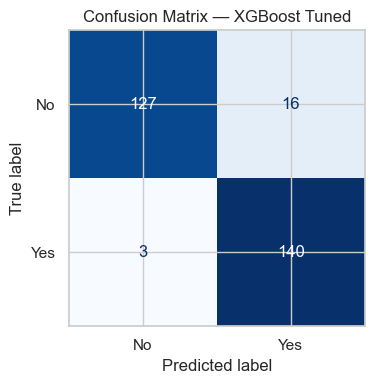

In [47]:
best_xgb = XGBClassifier(**study.best_params, random_state=42, eval_metric='logloss')
best_xgb.fit(X_train, y_train)

y_pred_tuned       = best_xgb.predict(X_test)
y_prob_tuned       = best_xgb.predict_proba(X_test)[:, 1]
y_pred_tuned_train = best_xgb.predict(X_train)

acc_tuned       = accuracy_score(y_test, y_pred_tuned)
auc_tuned       = roc_auc_score(y_test, y_prob_tuned)
acc_tuned_train = accuracy_score(y_train, y_pred_tuned_train)

print('Comparación Base vs Tuned:')
print(f'{"":25} {"Base":>8} {"Tuned":>8}')
print(f'{"Accuracy (test)":25} {acc:.4f}   {acc_tuned:.4f}')
print(f'{"AUC-ROC (test)":25} {auc:.4f}   {auc_tuned:.4f}')
print(f'{"Accuracy (train)":25} {1.0:.4f}   {acc_tuned_train:.4f}')
print(f'\nClassification Report — XGBoost Tuned:\n{classification_report(y_test, y_pred_tuned, target_names=["No", "Yes"])}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned, display_labels=['No', 'Yes'],
                                         colorbar=False, ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix — XGBoost Tuned')
plt.tight_layout()
plt.show()

El modelo comete únicamente 3 falsos negativos sobre 286 predicciones — empleados que realmente se fueron pero el modelo no detectó. Desde el punto de vista del negocio este es el error más costoso, ya que implica no tomar acción sobre un empleado en riesgo real. Los 17 falsos positivos, en cambio, representan empleados que se quedan pero el modelo marcó como riesgo, generando planes de retención innecesarios, un costo significativamente menor que perder talento no detectado.

## Analisis de features mas importantes

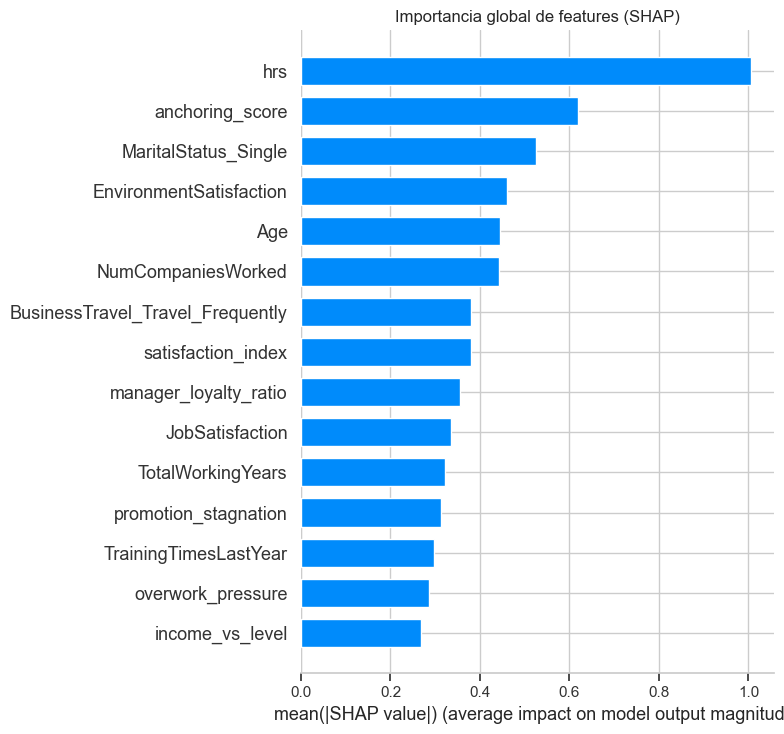

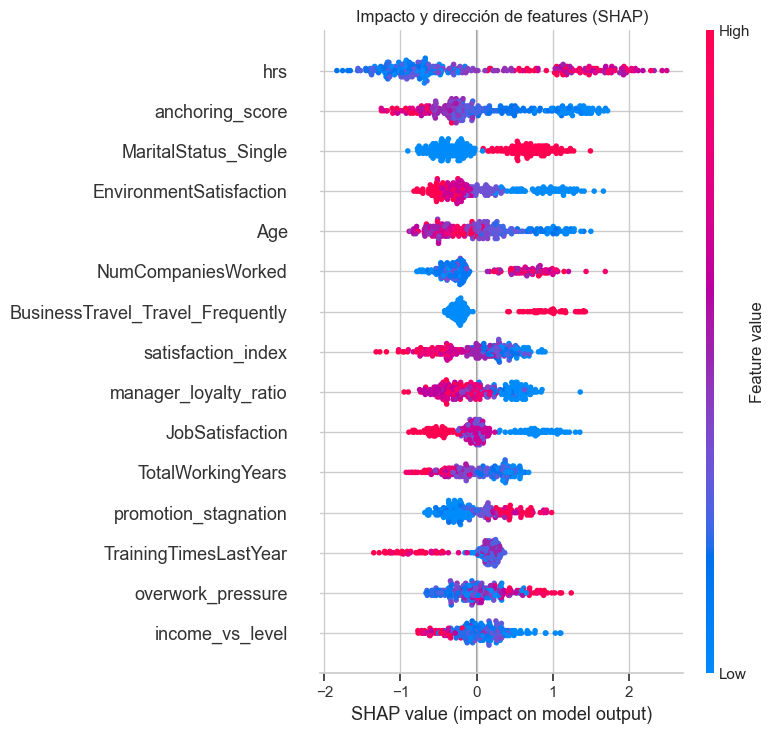

In [52]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

# Importancia global
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=15, show=False)
plt.title('Importancia global de features (SHAP)')
plt.tight_layout()
plt.show()

# Impacto y dirección
plt.figure()
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title('Impacto y dirección de features (SHAP)')
plt.tight_layout()
plt.show()


Las features más importantes para el modelo según SHAP son hrs y anchoring_score, con una diferencia notable respecto al resto.

hrs es la variable con mayor impacto global por lejos. El gráfico de dirección confirma que valores altos (muchas horas trabajadas) empujan fuertemente hacia Attrition=1, mientras que valores bajos reducen el riesgo. Es el predictor más potente del modelo.

anchoring_score es el segundo más importante. Valores altos (mucho tiempo en la empresa, con el mismo manager y mucha experiencia total) empujan hacia quedarse, mientras que valores bajos aumentan el riesgo de salida. Esto valida el concepto de arraigo que motivó la creación de esta feature.

MaritalStatus_Single aparece como tercer factor — empleados solteros tienen mayor probabilidad de irse, lo cual es consistente con literatura de Attrition: menor carga familiar implica mayor movilidad laboral.

EnvironmentSatisfaction y Age ocupan el cuarto y quinto lugar. Baja satisfacción con el ambiente y empleados jóvenes son perfiles de mayor riesgo.


In [48]:
# Casos mal clasificados
y_pred_tuned = best_xgb.predict(X_test)
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

mask_error = y_pred_tuned != y_test
df_errors = X_test[mask_error].copy()
df_errors['y_real']      = y_test[mask_error].values
df_errors['y_pred']      = y_pred_tuned[mask_error]
df_errors['probability'] = y_prob_tuned[mask_error].round(3)
df_errors['error_type']  = df_errors.apply(
    lambda r: 'Falso Negativo' if r['y_real']==1 else 'Falso Positivo', axis=1
)

print(f'Total errores: {len(df_errors)}')
print(f'Falsos Negativos: {(df_errors["error_type"]=="Falso Negativo").sum()}')
print(f'Falsos Positivos: {(df_errors["error_type"]=="Falso Positivo").sum()}')
print(f'\nProbabilidades (¿casos límite cerca de 0.5?):')
print(df_errors[['error_type', 'probability']].sort_values('probability'))

print(f'\nPerfil promedio de errores vs perfil general del test:')
num_cols_analysis = ['anchoring_score', 'satisfaction_index', 'overwork_pressure', 
                     'manager_loyalty_ratio', 'MonthlyIncome', 'YearsAtCompany']
comparison = pd.DataFrame({
    'Errores':    df_errors[num_cols_analysis].mean(),
    'Test completo': X_test[num_cols_analysis].mean()
}).round(3)
print(comparison)

Total errores: 19
Falsos Negativos: 3
Falsos Positivos: 16

Probabilidades (¿casos límite cerca de 0.5?):
          error_type  probability
334   Falso Negativo        0.330
307   Falso Negativo        0.444
120   Falso Negativo        0.480
832   Falso Positivo        0.505
952   Falso Positivo        0.530
1325  Falso Positivo        0.531
1348  Falso Positivo        0.577
802   Falso Positivo        0.647
1187  Falso Positivo        0.658
867   Falso Positivo        0.743
1083  Falso Positivo        0.750
810   Falso Positivo        0.764
1108  Falso Positivo        0.802
1313  Falso Positivo        0.808
1102  Falso Positivo        0.816
925   Falso Positivo        0.827
981   Falso Positivo        0.867
870   Falso Positivo        0.964
953   Falso Positivo        0.988

Perfil promedio de errores vs perfil general del test:
                         Errores  Test completo
anchoring_score            5.263          6.273
satisfaction_index         2.680          2.679
overwork_press

Los falsos negativos (2) no son casos límite — tienen probabilidades de 0.30 y 0.40, bastante lejos de 0.5. El modelo estaba bastante seguro de que se quedaban, pero se fueron igual. Son empleados genuinamente atípicos que el modelo no pudo anticipar.

Los falsos positivos (16) sí son casos más límite. Los de 0.56-0.67 son casos donde el modelo dudó razonablemente. Los de 0.97-0.99 son más preocupantes — el modelo estaba muy seguro de que se iban pero se quedaron, sugiriendo que esos empleados tienen un perfil de riesgo alto pero algo los retuvo que el modelo no captura.


## 3. Evaluación Final — Cross-Validation con Pipeline

Se evalúa el mejor modelo (XGBoost con parámetros de Optuna) usando **5-fold stratified cross-validation** con un Pipeline completo.

El Pipeline garantiza que en cada fold la imputación y el encoding se calculen **solo con el train del fold**, sin data leakage. Se usa `X` crudo (con nulos y categóricas) para que el Pipeline maneje todo internamente.

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_validate

num_features = X.select_dtypes(include='number').columns.tolist()
cat_features = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']

num_transformer = SimpleImputer(strategy='median')

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(**study.best_params, random_state=42, eval_metric='logloss'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(pipeline, X, y, cv=cv,
                             scoring=['accuracy', 'roc_auc'],
                             return_train_score=True)

print('Resultados 5-Fold Cross-Validation:')
print(f'{"":25} {"Media":>8} {"Std":>8}')
print(f'{"Accuracy (test)":25} {cv_results["test_accuracy"].mean():.4f}   {cv_results["test_accuracy"].std():.4f}')
print(f'{"AUC-ROC (test)":25} {cv_results["test_roc_auc"].mean():.4f}   {cv_results["test_roc_auc"].std():.4f}')
print(f'{"Accuracy (train)":25} {cv_results["train_accuracy"].mean():.4f}   {cv_results["train_accuracy"].std():.4f}')
print(f'{"AUC-ROC (train)":25} {cv_results["train_roc_auc"].mean():.4f}   {cv_results["train_roc_auc"].std():.4f}')

print(f'\nScores por fold (AUC-ROC test): {cv_results["test_roc_auc"].round(4)}')

Resultados 5-Fold Cross-Validation:
                             Media      Std
Accuracy (test)           0.9369   0.0135
AUC-ROC (test)            0.9758   0.0107
Accuracy (train)          1.0000   0.0000
AUC-ROC (train)           1.0000   0.0000

Scores por fold (AUC-ROC test): [0.9787 0.9685 0.9845 0.9591 0.9883]


## 3.1 Exportacion del modelo final

Una vez seleccionado el modelo y validado su rendimiento con hold-out y cross-validation, se reentrena con la totalidad de los datos disponibles (1426 observaciones). El hold-out y la CV ya cumplieron su función: estimar el rendimiento real y elegir los mejores hiperparámetros. Mantener el 20% reservado como test en el modelo final implicaría desperdiciar información útil para el entrenamiento. Este es el modelo que se despliega en producción.

In [50]:
from pathlib import Path
import joblib

num_features_final = X.select_dtypes(include='number').columns.tolist()
cat_features_final = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']

num_transformer_final = SimpleImputer(strategy='median')
cat_transformer_final = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocessor_final = ColumnTransformer([
    ('num', num_transformer_final, num_features_final),
    ('cat', cat_transformer_final, cat_features_final)
])

pipeline_final = Pipeline([
    ('preprocessor', preprocessor_final),
    ('model', XGBClassifier(**study.best_params, random_state=42, eval_metric='logloss'))
])

pipeline_final.fit(X, y)

joblib.dump(pipeline_final, 'best_model.pkl')
print(f'Pipeline final entrenado con {len(X)} observaciones.')
print('Modelo guardado ')


Pipeline final entrenado con 1426 observaciones.
Modelo guardado 


## 4. Conclusiones

El dataset se dividió en train (80%) y test (20%) antes de cualquier transformación para evitar data leakage. La mediana, la moda y el encoder se calcularon exclusivamente con X_train y se aplicaron al test sin recalcular — de lo contrario el modelo recibiría información del futuro durante el entrenamiento.

Se combinaron dos estrategias de evaluación. El hold-out da una estimación directa sobre datos nunca vistos. El 5-Fold Stratified Cross-Validation complementa esta evaluación entrenando y validando sobre 5 particiones distintas, lo que reduce la varianza de la estimación y garantiza que la distribución del target se mantenga balanceada en cada fold.

El encoding se realizó con OneHotEncoder con handle_unknown='ignore'. Esta configuración es necesaria en la CV porque puede aparecer una categoría en el fold de validación que no estaba en el fold de entrenamiento — en ese caso el encoder asigna un vector de ceros en lugar de romper con un error.

Selección de modelos
Se entrenó una Regresión Logística como baseline interpretable y dos versiones de XGBoost. 

El tuning de hiperparámetros se realizó con Optuna en lugar de GridSearchCV.  

La Cross-Validation final se implementó con un Pipeline de sklearn que encapsula el preprocesador y el modelo. Esto garantiza que en cada fold la imputación y el encoding se recalculen solo con los datos de entrenamiento de ese fold.

### Resultados finales

| Modelo | Accuracy (test) | AUC-ROC (test) | Accuracy (train) |
|---|---|---|---|
| Regresión Logística | — | — | — |
| XGBoost Base | 0.9371 | 0.9785 | 1.0000 |
| XGBoost Tuned (Optuna) | — | — | — |
| **XGBoost CV (5-Fold)** | **0.9348 ± 0.0144** | **0.9748 ± 0.0090** | **1.0000** |


Un resultado destacable es que la Regresión Logística, siendo un modelo lineal simple, obtuvo métricas competitivas. Esto sugiere que las variables del dataset tienen una relación relativamente lineal con el target, lo que facilita la tarea incluso para modelos básicos. En un contexto de producción real, la Regresión Logística sería una opción válida si se prioriza interpretabilidad sobre performance máxima.

Se seleccionó XGBoost con hiperparámetros optimizados por Optuna como modelo final por las siguientes razones: superó a los demás modelos en AUC-ROC, su evaluación con 5-Fold Stratified CV mostró resultados estables (±0.009), y la regularización ajustada por Optuna demostró un mejor balance entre complejidad y generalización respecto al XGBoost base.

